# Рубежный контроль №1
## Тема: Методы обработки данных

**Выполнил:** Пац Илья Николаевич  
**Группа:** ИУ5-23М

---
## Загрузка и первичный анализ данных

Для выполнения работы используется набор данных **Tips** из библиотеки `seaborn`.

**Описание признаков:**
- `total_bill` — общий счёт (числовой)
- `tip` — сумма чаевых (числовой)
- `sex` — пол официанта (категориальный)
- `smoker` — курит ли клиент (категориальный)
- `day` — день недели (категориальный)
- `time` — время суток (категориальный)
- `size` — количество человек за столом (числовой)

In [3]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
df = sns.load_dataset('tips')
print(f'Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(10)

Размер данных: 244 строк, 7 столбцов


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Построим «ящик с усами» для признака `total_bill`.

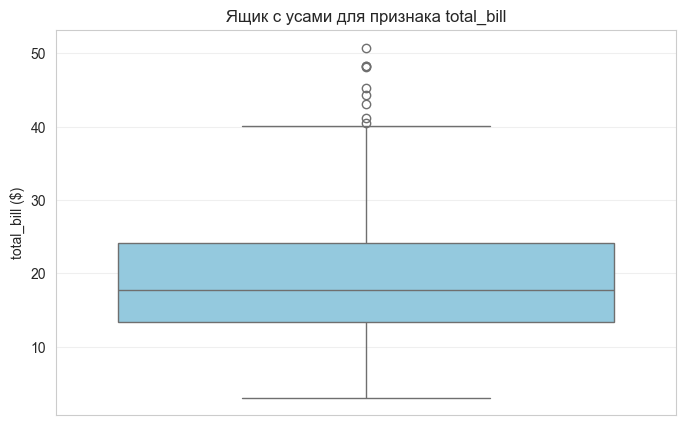

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='total_bill', color='skyblue')
plt.title('Ящик с усами для признака total_bill')
plt.ylabel('total_bill ($)')
plt.grid(axis='y', alpha=0.3)
plt.show()

---
## Задача №8: Устранение пропусков методом заполнения модой

Нужно заполнить пропуски в числовом признаке `tip` с использованием моды.

In [9]:
# копия данных и внесение пропусков
df_task8 = df.copy()
feature_name = 'tip'

np.random.seed(42)
n_missing = int(len(df_task8) * 0.1)
missing_idx = np.random.choice(df_task8.index, size=n_missing, replace=False)
df_task8.loc[missing_idx, feature_name] = np.nan

print(f'Внесено пропусков: {df_task8[feature_name].isna().sum()} ({df_task8[feature_name].isna().mean()*100:.1f}%)')
df_task8[feature_name].head(15)

Внесено пропусков: 24 (9.8%)


0     1.01
1     1.66
2     3.50
3     3.31
4     3.61
5     4.71
6      NaN
7     3.12
8     1.96
9      NaN
10    1.71
11    5.00
12    1.57
13    3.00
14    3.02
Name: tip, dtype: float64

In [10]:
# вычисляем моду и заполняем пропуски
mode_val = df_task8[feature_name].mode()[0]
print(f'Мода признака "{feature_name}": {mode_val}')

df_task8[feature_name] = df_task8[feature_name].fillna(mode_val)

# проверка
print(f'Пропусков после заполнения: {df_task8[feature_name].isna().sum()}')
print()
print('Первые 15 значений после обработки:')
df_task8[feature_name].head(15)

Мода признака "tip": 2.0
Пропусков после заполнения: 0

Первые 15 значений после обработки:


0     1.01
1     1.66
2     3.50
3     3.31
4     3.61
5     4.71
6     2.00
7     3.12
8     1.96
9     2.00
10    1.71
11    5.00
12    1.57
13    3.00
14    3.02
Name: tip, dtype: float64

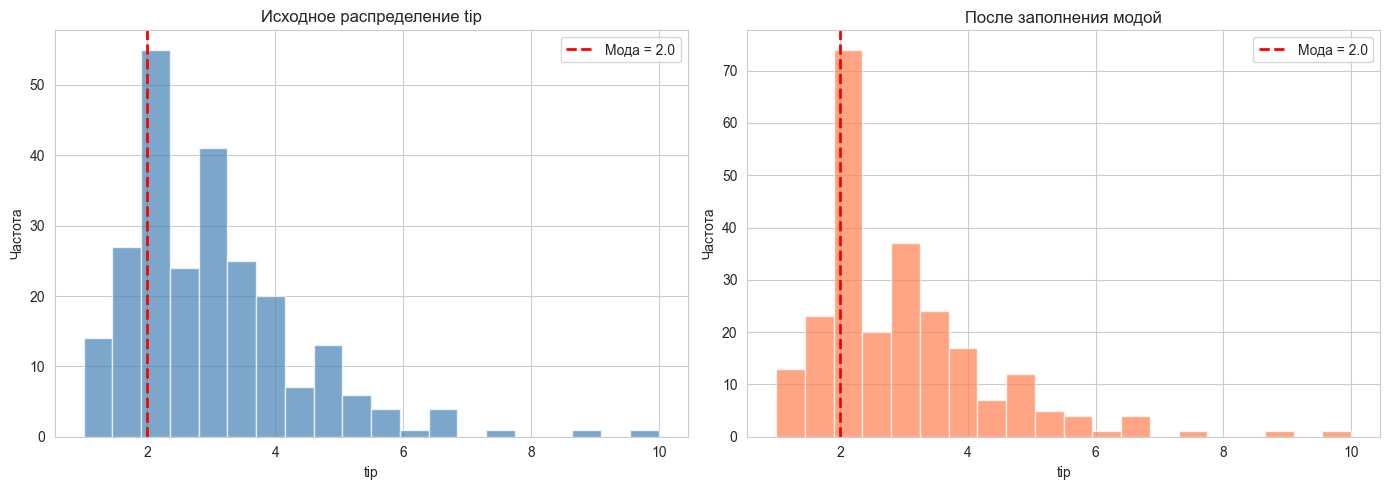

In [12]:
# Визуализация распределения до и после
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[feature_name], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(mode_val, color='red', ls='--', lw=2, label=f'Мода = {mode_val}')
axes[0].set_title(f'Исходное распределение {feature_name}')
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(df_task8[feature_name], bins=20, color='coral', edgecolor='white', alpha=0.7)
axes[1].axvline(mode_val, color='red', ls='--', lw=2, label=f'Мода = {mode_val}')
axes[1].set_title(f'После заполнения модой')
axes[1].set_xlabel(feature_name)
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Задача №28: Обнаружение и замена выбросов по IQR

Найти выбросы в признаке `total_bill` с помощью межквартильного размаха и заменить их на граничные значения.

In [13]:
# вычисляем квартили, IQR и границы
df_task28 = df.copy()
feature = 'total_bill'

Q1 = df_task28[feature].quantile(0.25)
Q3 = df_task28[feature].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Признак: {feature}')
print(f'Q1 = {Q1:.2f}')
print(f'Q3 = {Q3:.2f}')
print(f'IQR = {IQR:.2f}')
print(f'Нижняя граница = {lower:.2f}')
print(f'Верхняя граница = {upper:.2f}')

Признак: total_bill
Q1 = 13.35
Q3 = 24.13
IQR = 10.78
Нижняя граница = -2.82
Верхняя граница = 40.30


In [14]:
# обнаружение выбросов
outliers = (df_task28[feature] < lower) | (df_task28[feature] > upper)
print(f'Найдено выбросов: {outliers.sum()} ({outliers.sum()/len(df_task28)*100:.2f}%)')
print()
print('Значения-выбросы:')
df_task28.loc[outliers, [feature]]

Найдено выбросов: 9 (3.69%)

Значения-выбросы:


,total_bill
59,48.27
102,44.30
142,41.19
156,48.17
170,50.81
182,45.35
184,40.55
197,43.11
212,48.33


In [15]:
# замена выбросов на границы и проверка
n_low = (df_task28[feature] < lower).sum()
n_high = (df_task28[feature] > upper).sum()

df_task28[feature] = df_task28[feature].clip(lower=lower, upper=upper)

print(f'Заменено на нижнюю границу ({lower:.2f}): {n_low}')
print(f'Заменено на верхнюю границу ({upper:.2f}): {n_high}')
print(f'Всего заменено: {n_low + n_high}')

outliers_after = ((df_task28[feature] < lower) | (df_task28[feature] > upper)).sum()
print(f'Выбросов после обработки: {outliers_after}')

Заменено на нижнюю границу (-2.82): 0
Заменено на верхнюю границу (40.30): 9
Всего заменено: 9
Выбросов после обработки: 0


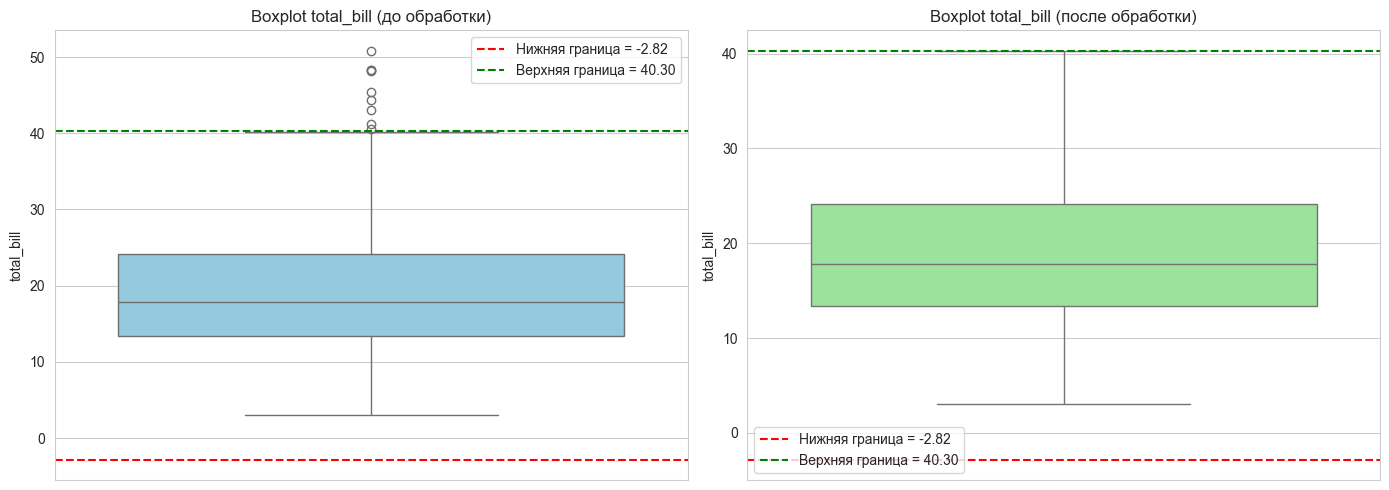

In [17]:
# Визуализация boxplot до и после
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, y=feature, ax=axes[0], color='skyblue')
axes[0].axhline(lower, color='red', ls='--', lw=1.5, label=f'Нижняя граница = {lower:.2f}')
axes[0].axhline(upper, color='green', ls='--', lw=1.5, label=f'Верхняя граница = {upper:.2f}')
axes[0].set_title(f'Boxplot {feature} (до обработки)')
axes[0].set_ylabel(feature)
axes[0].legend()

sns.boxplot(data=df_task28, y=feature, ax=axes[1], color='lightgreen')
axes[1].axhline(lower, color='red', ls='--', lw=1.5, label=f'Нижняя граница = {lower:.2f}')
axes[1].axhline(upper, color='green', ls='--', lw=1.5, label=f'Верхняя граница = {upper:.2f}')
axes[1].set_title(f'Boxplot {feature} (после обработки)')
axes[1].set_ylabel(feature)
axes[1].legend()

plt.tight_layout()
plt.show()